**Explore**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
%matplotlib inline

In [ ]:
df=pd.read_csv("/content/diabetes (1).csv")

In [ ]:
df.head()

,id,'preg','plas','pres','skin','insu','mass','pedi','age','class'
0,1,6,148,72,35,0,33.6,0.627,50,tested_positive
1,2,1,85,66,29,0,26.6,0.351,31,tested_negative
2,3,8,183,64,0,0,23.3,0.672,32,tested_positive
3,4,1,89,66,23,94,28.1,0.167,21,tested_negative
4,5,0,137,40,35,168,43.1,2.288,33,tested_positive


In [ ]:
df.tail()

,id,'preg','plas','pres','skin','insu','mass','pedi','age','class'
763,764,10,101,76,48,180,32.9,0.171,63,tested_negative
764,765,2,122,70,27,0,36.8,0.340,27,tested_negative
765,766,5,121,72,23,112,26.2,0.245,30,tested_negative
766,767,1,126,60,0,0,30.1,0.349,47,tested_positive
767,768,1,93,70,31,0,30.4,0.315,23,tested_negative


In [ ]:
df.shape

(768, 10)

In [ ]:
df.size

7680

In [ ]:
df.columns

Index(['id', ''preg'', ''plas'', ''pres'', ''skin'', ''insu'', ''mass'',
       ''pedi'', ''age'', ''class''],
      dtype='object')

In [ ]:
df.loc[: ,["'mass'","'age'"]]

,'mass','age'
0,33.6,50
1,26.6,31
2,23.3,32
3,28.1,21
4,43.1,33
...,...,...
763,32.9,63
764,36.8,27
765,26.2,30
766,30.1,47


In [ ]:
df["'class'"].value_counts()

,count
'class',
tested_negative,500
tested_positive,268


In [ ]:
df["'class'"].value_counts()/len(df)

,count
'class',
tested_negative,0.651042
tested_positive,0.348958


In [ ]:
df[df["'age'"]>40]["'class'"].value_counts()

,count
'class',
tested_positive,102
tested_negative,92


In [ ]:
pd.crosstab(df["'age'"],df["'class'"])

'class',tested_negative,tested_positive
'age',,
21,58,5
22,61,11
23,31,7
24,38,8
25,34,14
26,25,8
27,24,8
28,25,10
29,16,13


In [ ]:
df.rename(columns={
    "'preg'":"preg",
    "'plas'":"plas",
    "'pres'":"pres",
    "'skin'":'skin',
    "'insu'":"insu",
    "'mass'":"mass",
    "'pedi'":"pedi",
    "'age'":"age",
    "'class'":"class"
},inplace=True)

In [ ]:
df.columns

Index(['id', 'preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age',
       'class'],
      dtype='object')

**Cleaning**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      768 non-null    int64  
 1   preg    768 non-null    int64  
 2   plas    768 non-null    int64  
 3   pres    768 non-null    int64  
 4   skin    768 non-null    int64  
 5   insu    768 non-null    int64  
 6   mass    768 non-null    float64
 7   pedi    768 non-null    float64
 8   age     768 non-null    int64  
 9   class   768 non-null    object 
dtypes: float64(2), int64(7), object(1)
memory usage: 60.1+ KB


In [ ]:
df.isna().sum()

,0
id,0
preg,0
plas,0
pres,0
skin,0
insu,0
mass,0
pedi,0
age,0
class,0


In [ ]:
df.nunique()

,0
id,768
preg,17
plas,136
pres,47
skin,51
insu,186
mass,248
pedi,517
age,52
class,2


In [ ]:
df["class"]=df['class'].map({
    "tested_negative":0,
    "tested_positive":1
})


In [ ]:
df['class'].unique()

array([1, 0])

In [ ]:
cols = ["plas", "pres", "skin", "insu", "mass"]

print((df[cols] == 0).sum())

plas      5
pres     35
skin    227
insu    374
mass     11
dtype: int64


In [ ]:
df[cols] = df[cols].replace(0, np.nan)


In [ ]:
df.isna().sum()

,0
id,0
preg,0
plas,5
pres,35
skin,227
insu,374
mass,11
pedi,0
age,0
class,0


<Axes: >

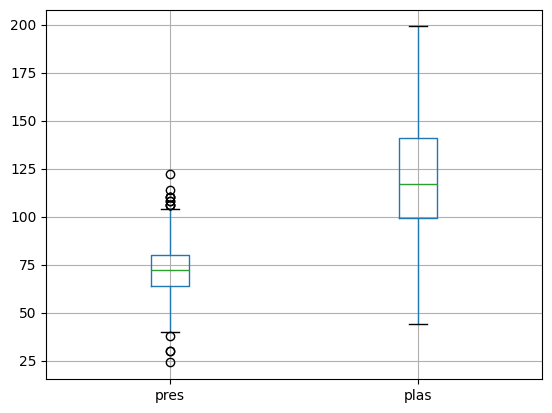

In [ ]:
df.boxplot(column=["pres","plas"])

<Axes: >

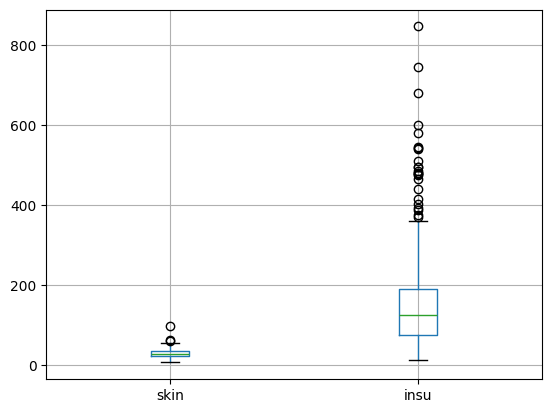

In [ ]:
df.boxplot(column=["skin","insu"])

<Axes: >

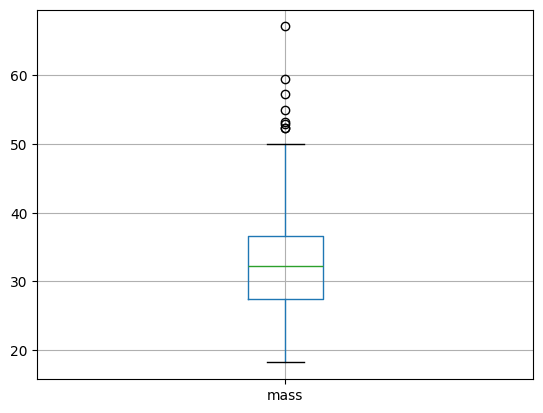

In [ ]:
df.boxplot(column=["mass"])

In [ ]:
#capping
Q1 = df["insu"].quantile(0.25)
Q3 = df["insu"].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["insu"] = df["insu"].clip(lower, upper)

<Axes: >

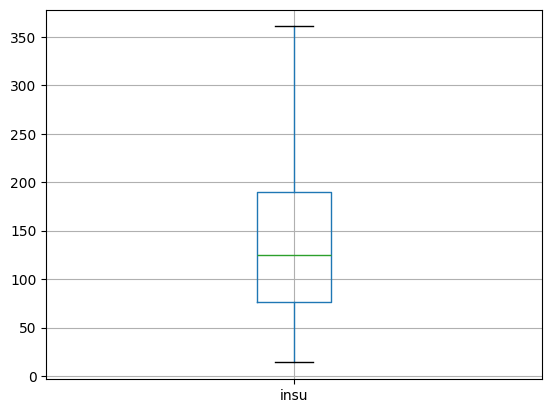

In [ ]:
df.boxplot(column=["insu"])

**fill**

In [ ]:
df['plas']=df['plas'].fillna(df['plas'].mean())
df['pres']=df['pres'].fillna(df['pres'].median())
df['skin']=df['skin'].fillna(df['skin'].median())
df['insu']=df['insu'].fillna(df['insu'].median())
df['mass']=df['mass'].fillna(df['mass'].median())

In [ ]:
df.isna().sum()

,0
id,0
preg,0
plas,0
pres,0
skin,0
insu,0
mass,0
pedi,0
age,0
class,0


In [ ]:
df.drop("id",axis=1,inplace=True)


KeyError: "['id'] not found in axis"

In [ ]:
df.columns

Index(['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age', 'class'], dtype='object')

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,id,preg,plas,pres,skin,insu,mass,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,384.500000,3.845052,121.686763,72.386719,29.108073,136.029948,32.455208,0.471876,33.240885,0.348958
std,221.846794,3.369578,30.435949,12.096642,8.791221,65.560632,6.875177,0.331329,11.760232,0.476951
min,1.000000,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,192.750000,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,384.500000,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,576.250000,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,768.000000,17.000000,199.000000,122.000000,99.000000,360.625000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df.to_csv("cleann Data.csv",index=False)

In [ ]:
df.head()

,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


**Data Visualization**

<Axes: xlabel='class', ylabel='count'>

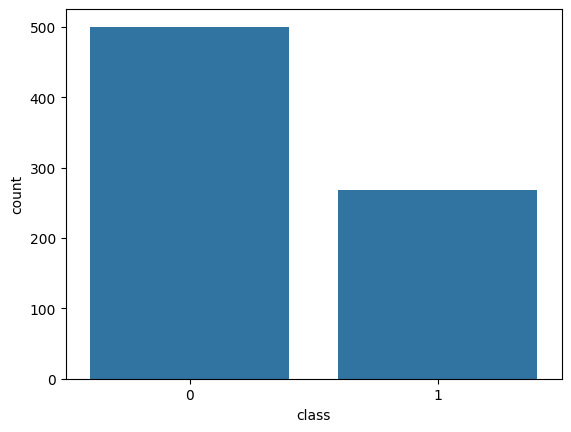

In [ ]:
sb.countplot(x="class",data=df)


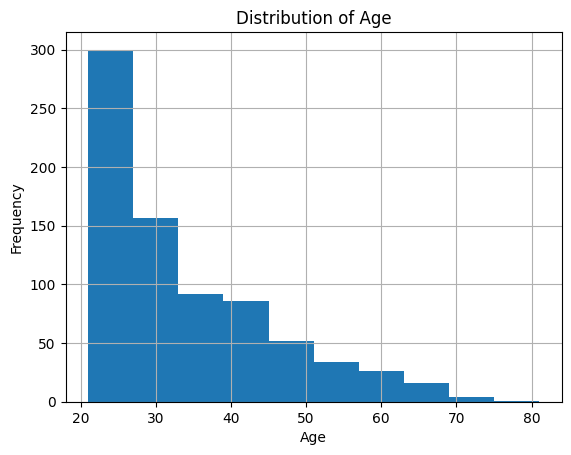

In [ ]:
df['age'].hist()
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

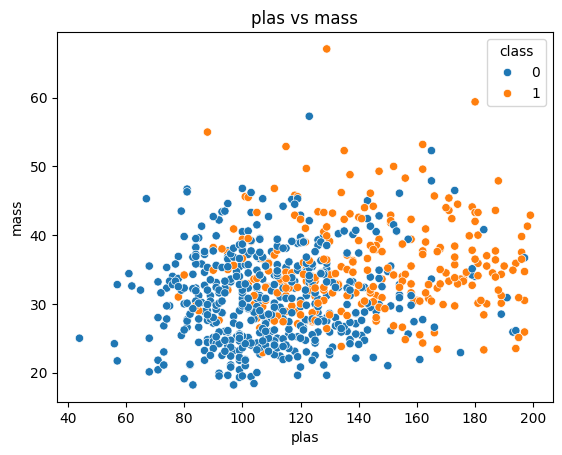

In [ ]:
sb.scatterplot(x="plas",y="mass",hue="class",data=df)
plt.title("plas vs mass")
plt.show()

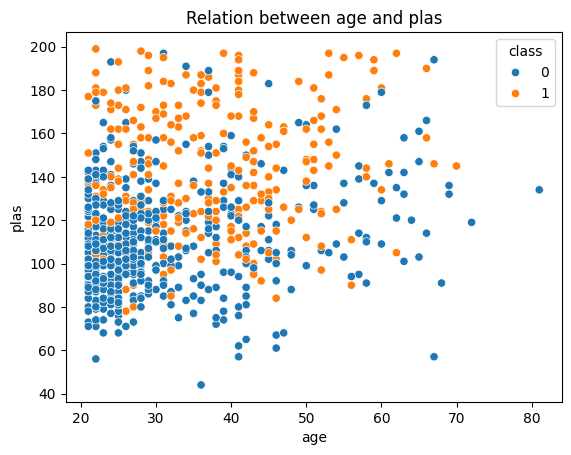

In [ ]:
sb.scatterplot(x="age",y="plas",hue="class",data=df)
plt.title("Relation between age and plas")
plt.show()

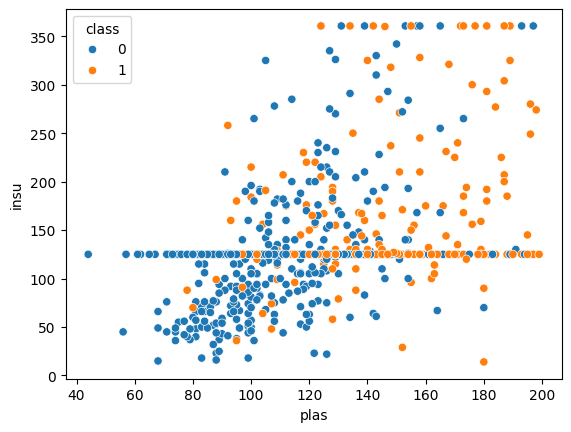

In [ ]:
sb.scatterplot(x="plas",y="insu",hue="class",data=df)
plt.show()

**Model**

In [ ]:
df=pd.read_csv("/content/cleann Data.csv")

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop("class", axis=1), df["class"], test_size=0.2, random_state=0)

In [ ]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred = log_reg.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

Accuracy: 0.8051948051948052
